In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("House_price.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (999, 6)


,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


In [3]:
# Dataset dimensions
print("Rows and columns:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# First 5 rows
print("\nFirst 5 rows:")
print(df.head())

Rows and columns: (999, 6)

Column names:
['Avg. Area Income', 'House Age', 'Number of Rooms', 'Number of Bedrooms', 'Area Population', 'Price']

Data types:
Avg. Area Income      float64
House Age             float64
Number of Rooms       float64
Number of Bedrooms    float64
Area Population       float64
Price                 float64
dtype: object

First 5 rows:
   Avg. Area Income  House Age  Number of Rooms  Number of Bedrooms  \
0       79545.45857   5.682861         7.009188                4.09   
1       79248.64245   6.002900         6.730821                3.09   
2       61287.06718   5.865890         8.512727                5.13   
3       63345.24005   7.188236         5.586729                3.26   
4       59982.19723   5.040555         7.839388                4.23   

   Area Population         Price  
0      23086.80050  1.059034e+06  
1      40173.07217  1.505891e+06  
2      36882.15940  1.058988e+06  
3      34310.24283  1.260617e+06  
4      26354.10947  6.309435e+0

In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Avg. Area Income      0
House Age             0
Number of Rooms       0
Number of Bedrooms    0
Area Population       0
Price                 0
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df.describe()

,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price
count,999.000000,999.000000,999.000000,999.000000,999.000000,9.990000e+02
mean,68783.805627,6.058283,7.016825,3.972973,35849.447580,1.249194e+06
std,10642.485432,0.988609,0.997815,1.234513,9745.900912,3.502090e+05
min,17796.631190,3.278228,3.236194,2.000000,172.610686,1.520719e+05
25%,61789.040515,5.407817,6.353208,3.140000,29136.252095,1.019847e+06
50%,68864.282300,6.043693,7.058765,4.040000,35991.720640,1.242979e+06
75%,75863.942790,6.766865,7.680286,4.500000,42733.057115,1.474933e+06
max,107701.748400,8.764786,9.710217,6.500000,69575.449460,2.469066e+06


In [17]:
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(999, 6)
Avg. Area Income      0
House Age             0
Number of Rooms       0
Number of Bedrooms    0
Area Population       0
Price                 0
dtype: int64
       Avg. Area Income   House Age  Number of Rooms  Number of Bedrooms  \
count        999.000000  999.000000       999.000000          999.000000   
mean       68783.805627    6.058283         7.016825            3.972973   
std        10642.485432    0.988609         0.997815            1.234513   
min        17796.631190    3.278228         3.236194            2.000000   
25%        61789.040515    5.407817         6.353208            3.140000   
50%        68864.282300    6.043693         7.058765            4.040000   
75%        75863.942790    6.766865         7.680286            4.500000   
max       107701.748400    8.764786         9.710217            6.500000   

       Area Population         Price  
count       999.000000  9.990000e+02  
mean      35849.447580  1.249194e+06  
std        9745.900912  3.502090

In [18]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.39,165721.82,120140.7 , -3922.28, 14.74]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','House Age','Number of Rooms','Number of Bedrooms', 'Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.579e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [21]:
pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2: 0.9269373453153578
RMSE: 96103.16805548356


In [22]:
print(dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)

{'Avg. Area Income': np.float64(21.394796109822426), 'House Age': np.float64(165721.82451279328), 'Number of Rooms': np.float64(120140.70074967465), 'Number of Bedrooms': np.float64(-3922.276991376946), 'Area Population': np.float64(14.739457276649773)}
Intercept: -2578730.001225243


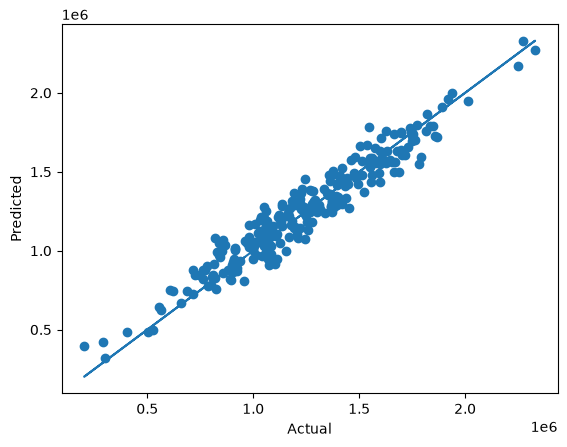

In [23]:
plt.scatter(y_test, pred)
plt.plot(y_test, y_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()